In [3]:
import ast
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter
from itertools import combinations
from igraph import Graph

# ============================================================
# CONFIGURATION
# ============================================================

RULE_FILE = "../17_NuevoAnalisisP1/reglas_abac.txt"
THRESHOLD = 0.5
# OUTPUT_GRAPH = "../23_PolicyNetworkAnalysis/rule_network_hc_d.graphml"

# ============================================================
# LOAD RULES
# ============================================================

# ============================================================
# CENTRALITY METRICS AS NODE ATTRIBUTES
# ============================================================

def add_centrality_attributes(g):

    print("\nComputing centrality metrics...")

    # --------------------------------------------------------
    # Degree
    # --------------------------------------------------------

    degree_values = g.degree()

    g.vs["degree"] = degree_values

    # --------------------------------------------------------
    # Betweenness
    # --------------------------------------------------------

    betweenness_values = g.betweenness()

    g.vs["betweenness"] = betweenness_values

    # --------------------------------------------------------
    # Closeness
    # --------------------------------------------------------

    closeness_values = g.closeness()

    g.vs["closeness"] = closeness_values

    # --------------------------------------------------------
    # Eigenvector Centrality
    # --------------------------------------------------------

    eigenvector_values = g.eigenvector_centrality(
        weights=g.es["weight"]
    )

    g.vs["eigenvector"] = eigenvector_values

    # --------------------------------------------------------
    # Pagerank (recommended)
    # --------------------------------------------------------

    pagerank_values = g.pagerank(
        weights=g.es["weight"]
    )

    g.vs["pagerank"] = pagerank_values

    # --------------------------------------------------------
    # Local Clustering Coefficient
    # --------------------------------------------------------

    clustering_values = g.transitivity_local_undirected()

    g.vs["local_clustering"] = clustering_values

    print("Centrality attributes added!")

    return g

def load_rules(file_path):

    rules = []

    with open(file_path, "r", encoding="utf-8") as f:

        for idx, line in enumerate(f):

            line = line.strip()

            if not line:
                continue

            try:

                parsed = ast.literal_eval(line)

                id_com = parsed[0][1]

                attributes = parsed[1]

                feature_set = set()

                for attr_name, attr_value in attributes:
                    feature_set.add((attr_name, str(attr_value)))

                rules.append({
                    "idx": idx,
                    "id_com": id_com,
                    "features": feature_set,
                    "raw": parsed
                })

            except Exception as e:
                print(f"Error parsing line {idx}: {e}")

    return rules


# ============================================================
# JACCARD SIMILARITY
# ============================================================

def jaccard_similarity(set_a, set_b):

    intersection = len(set_a.intersection(set_b))
    union = len(set_a.union(set_b))

    if union == 0:
        return 0.0

    return intersection / union


# ============================================================
# BUILD NETWORK
# ============================================================

def build_rule_network(rules, threshold):

    g = Graph()
    g.add_vertices(len(rules))

    # --------------------------------------------------------

    for rule in rules:

        v = rule["idx"]

        g.vs[v]["rule_id"] = v
        g.vs[v]["id_com"] = rule["id_com"]
        g.vs[v]["num_features"] = len(rule["features"])

    # --------------------------------------------------------

    edges = []
    weights = []

    for r1, r2 in combinations(rules, 2):

        sim = jaccard_similarity(
            r1["features"],
            r2["features"]
        )

        if sim > threshold:

            edges.append((r1["idx"], r2["idx"]))
            weights.append(sim)

    g.add_edges(edges)
    g.es["weight"] = weights

    return g


# ============================================================
# BASIC ANALYSIS
# ============================================================

def analyze_network(g):

    print("\n================================")
    print("RULE NETWORK ANALYSIS")
    print("================================")

    print(f"Nodes: {g.vcount()}")
    print(f"Edges: {g.ecount()}")

    density = g.density()
    print(f"Density: {density:.6f}")

    degrees = g.degree()

    print(f"Average degree: {np.mean(degrees):.4f}")
    print(f"Max degree: {np.max(degrees)}")

    clustering = g.transitivity_avglocal_undirected()
    print(f"Average clustering coefficient: {clustering:.4f}")

    comps = g.connected_components()

    print(f"Connected components: {len(comps)}")
    print(f"Giant component size: {max(comps.sizes())}")

    # --------------------------------------------------------
    # Average shortest path length
    # --------------------------------------------------------

    giant = comps.giant()

    avg_shortest = giant.average_path_length()

    print(f"Average shortest path length: {avg_shortest:.4f}")

    # --------------------------------------------------------
    # Community detection
    # --------------------------------------------------------

    communities = g.community_multilevel(weights=g.es["weight"])

    modularity = communities.modularity

    print(f"Communities detected: {len(communities)}")
    print(f"Modularity: {modularity:.4f}")

    print("================================\n")


# ============================================================
# PLOT: EDGE WEIGHT DISTRIBUTION
# ============================================================

def plot_edge_weight_distribution(g):

    if g.ecount() == 0:
        print("No edges to plot.")
        return

    weights = g.es["weight"]

    plt.figure(figsize=(8, 5))

    plt.hist(weights, bins=30)

    plt.xlabel("Edge Weight (Jaccard Similarity)")
    plt.ylabel("Frequency")
    plt.title("Edge Weight Distribution")

    plt.grid(True)

    plt.tight_layout()
    plt.show()


# ============================================================
# PLOT: DEGREE DISTRIBUTION
# ============================================================

def plot_degree_distribution(g):

    degrees = g.degree()

    degree_count = Counter(degrees)

    x = list(degree_count.keys())
    y = list(degree_count.values())

    plt.figure(figsize=(8, 5))

    plt.scatter(x, y)

    plt.xlabel("Degree")
    plt.ylabel("Frequency")
    plt.title("Degree Distribution")

    plt.grid(True)

    plt.tight_layout()
    plt.show()


# ============================================================
# CENTRALITY ANALYSIS
# ============================================================

def compute_centralities(g):

    centralities = {}

    # --------------------------------------------------------
    # Degree Centrality
    # --------------------------------------------------------

    centralities["degree"] = g.degree()

    # --------------------------------------------------------
    # Betweenness Centrality
    # --------------------------------------------------------

    centralities["betweenness"] = g.betweenness()

    # --------------------------------------------------------
    # Closeness Centrality
    # --------------------------------------------------------

    centralities["closeness"] = g.closeness()

    # --------------------------------------------------------
    # Eigenvector Centrality
    # --------------------------------------------------------

    centralities["eigenvector"] = g.eigenvector_centrality(
        weights=g.es["weight"]
    )

    return centralities


# ============================================================
# PLOT CENTRALITY DISTRIBUTIONS
# ============================================================

def plot_centrality_distribution(values, title):

    plt.figure(figsize=(8, 5))

    plt.hist(values, bins=30)

    plt.xlabel("Centrality Value")
    plt.ylabel("Frequency")
    plt.title(title)

    plt.grid(True)

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZE NETWORK USING CENTRALITY
# ============================================================

def visualize_network_by_centrality(g, values, title):

    layout = g.layout("fr")

    # --------------------------------------------------------
    # Normalize node size
    # --------------------------------------------------------

    values = np.array(values)

    if np.max(values) == np.min(values):
        node_sizes = [20] * len(values)
    else:
        node_sizes = 10 + (
            (values - np.min(values))
            / (np.max(values) - np.min(values))
        ) * 40

    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(10, 10))

    igraph_plot = g.copy()

    visual_style = {
        "layout": layout,
        "vertex_size": node_sizes,
        "vertex_label": None,
        "edge_width": 0.3,
        "bbox": (800, 800),
        "margin": 40,
        "target": ax
    }

    from igraph import plot

    plot(igraph_plot, **visual_style)

    plt.title(title)

    plt.show()


def spanning_trees_count(g):

    L = np.array(g.laplacian())

    # Teorema Kirchhoff
    L_reduced = np.delete(L, 0, axis=0)
    L_reduced = np.delete(L_reduced, 0, axis=1)

    return round(abs(np.linalg.det(L_reduced)))


def C1e_ST(g):

    n = g.vcount()

    values = set()

    for eid in range(g.ecount()):

        h = g.copy()
        h.delete_edges([eid])

        st = spanning_trees_count(h)
        #print(st)
        values.add(st)

    N1e_ST = len(values)

    mcu = max(n**1.68 - 10, 1)

    return (N1e_ST - 1)/(mcu - 1)

def graph_signature(g):

    A = np.array(g.get_adjacency().data)

    deg = np.diag(g.degree())

    L = deg - A

    Q = deg + A

    eigL = tuple(
        np.round(
            np.sort(np.linalg.eigvals(L).real),
            8
        )
    )

    eigQ = tuple(
        np.round(
            np.sort(np.linalg.eigvals(Q).real),
            8
        )
    )

    return (eigL, eigQ)


def C1e_spec(g):

    n = g.vcount()

    signatures = set()

    for eid in range(g.ecount()):

        h = g.copy()

        h.delete_edges([eid])

        signatures.add(
            graph_signature(h)
        )

    N1e_spec = len(signatures)

    mcu = max(n**1.68 - 10, 1)

    return (N1e_spec - 1)/(mcu - 1)

# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":

    print("Loading rules...")
    rules = load_rules(RULE_FILE)

    print(f"Rules loaded: {len(rules)}")

    print("Building rule network...")
    G = build_rule_network(rules, THRESHOLD)

    print(G.summary())

    # --------------------------------------------------------

    #analyze_network(G)

    #c1_st = C1e_ST(G)
    #print("C1e_ST =", c1_st)

    #c1_spec = C1e_spec(G)
    #print("C1e_spec =", c1_spec)


Loading rules...
Rules loaded: 156
Building rule network...
IGRAPH U-W- 156 621 -- 
+ attr: id_com (v), num_features (v), rule_id (v), weight (e)


In [2]:
import igraph as ig
import numpy as np

def get_m_cu(n):
    """
    Calcula el límite superior heurístico del número de aristas 
    del grafo más complejo para n nodos.
    """
    return (n ** 1.68) - 10

def calculate_C1e_ST(graph):
    """
    Calcula la métrica de complejidad C1e,ST basada en el número 
    de árboles de expansión de los subgrafos.
    """
    n = graph.vcount()
    if n < 4:
        return 0.0  # La heurística m_cu no tiene sentido para grafos muy pequeños

    m_cu = get_m_cu(n)
    
    # Almacenará los números de árboles de expansión únicos
    unique_spanning_trees = set()
    
    # Iterar sobre cada arista para crear los subgrafos (eliminando una arista)
    for edge in graph.es:
        # Crear copia del grafo y eliminar la arista actual
        g_prime = graph.copy()
        g_prime.delete_edges(edge.index)
        
        # Obtener la matriz Laplaciana
        L = np.array(g_prime.laplacian())
        
        # Teorema de Kirchhoff: Determinante del Laplaciano reducido
        # Eliminamos la primera fila y la primera columna
        L_reduced = L[1:, 1:]
        
        # Calcular el determinante (número de árboles de expansión)
        # Redondeamos para corregir errores de precisión de punto flotante
        num_trees = round(np.linalg.det(L_reduced))
        
        unique_spanning_trees.add(num_trees)
        
    N_1e_ST = len(unique_spanning_trees)
    
    # Calcular la métrica normalizada
    C1e_ST = (N_1e_ST - 1) / (m_cu - 1)
    
    # Asegurarnos de que el valor se mantenga en el rango [0, 1)
    return max(0.0, float(C1e_ST))

def calculate_C1e_spec(graph):
    """
    Calcula la métrica de complejidad C1e,spec basada en el espectro 
    de la matriz Laplaciana y la Laplaciana sin signo.
    """
    n = graph.vcount()
    if n < 4:
        return 0.0

    m_cu = get_m_cu(n)
    
    # Almacenará las tuplas de espectros únicos
    unique_spectra = set()
    
    for edge in graph.es:
        g_prime = graph.copy()
        g_prime.delete_edges(edge.index)
        
        # 1. Matriz Laplaciana (L = Grados - Adyacencia)
        L = np.array(g_prime.laplacian())
        
        # 2. Matriz Laplaciana sin signo (Q = Grados + Adyacencia)
        A = np.array(g_prime.get_adjacency().data)
        degrees = g_prime.degree()
        D = np.diag(degrees)
        Q = D + A
        
        # Calcular valores propios (espectro)
        eigvals_L = np.linalg.eigvalsh(L)
        eigvals_Q = np.linalg.eigvalsh(Q)
        
        # Ordenar y redondear los valores propios a 5 decimales
        # para evitar problemas de hash y precisión numérica
        eigvals_L_rounded = tuple(np.round(np.sort(eigvals_L), decimals=5))
        eigvals_Q_rounded = tuple(np.round(np.sort(eigvals_Q), decimals=5))
        
        # La "firma" del subgrafo es la combinación de ambos espectros
        subgraph_signature = (eigvals_L_rounded, eigvals_Q_rounded)
        unique_spectra.add(subgraph_signature)
        
    N_1e_spec = len(unique_spectra)
    
    # Calcular la métrica normalizada
    C1e_spec = (N_1e_spec - 1) / (m_cu - 1)
    
    return max(0.0, float(C1e_spec))


# Crear un grafo aleatorio (Erdős-Rényi) para probar
# 7 nodos y 15 aristas (basado en el n=7 más complejo del paper)
g = G

c_spec = calculate_C1e_spec(g)
    

print(f"Métrica C1e,spec: {c_spec:.4f}")

# Si el grafo es disconexo, C1e_ST arrojará 0 árboles de expansión siempre.
# El paper asume grafos conectados.
if g.is_connected():
    c_st = calculate_C1e_ST(g)
    c_spec = calculate_C1e_spec(g)
    
    print(f"Métrica C1e,ST:   {c_st:.4f}")
    print(f"Métrica C1e,spec: {c_spec:.4f}")
else:
    print("El grafo generado no es conexo. Intenta con otro.")

Métrica C1e,spec: 0.0189
El grafo generado no es conexo. Intenta con otro.


In [10]:
import igraph as ig
import numpy as np

def get_m_cu(n):
    """Límite superior heurístico del número de aristas para n nodos."""
    return (n ** 1.68) - 10

def calculate_C1e_ST(graph):
    """Calcula C1e,ST para un componente conectado."""
    n = graph.vcount()
    if n < 4:
        return 0.0  # La heurística no aplica para grafos triviales

    m_cu = get_m_cu(n)
    unique_spanning_trees = set()
    
    for edge in graph.es:
        g_prime = graph.copy()
        g_prime.delete_edges(edge.index)
        
        # Si al quitar la arista el componente se desconecta, 
        # el número de árboles de expansión es 0 matemáticamente.
        L = np.array(g_prime.laplacian())
        L_reduced = L[1:, 1:]
        
        # Redondear para evitar errores de coma flotante
        num_trees = round(np.linalg.det(L_reduced))
        unique_spanning_trees.add(num_trees)
        
    N_1e_ST = len(unique_spanning_trees)
    return max(0.0, float((N_1e_ST - 1) / (m_cu - 1)))

def calculate_C1e_spec(graph):
    """Calcula C1e,spec para un componente conectado."""
    n = graph.vcount()
    if n < 4:
        return 0.0

    m_cu = get_m_cu(n)
    unique_spectra = set()
    
    for edge in graph.es:
        g_prime = graph.copy()
        g_prime.delete_edges(edge.index)
        
        L = np.array(g_prime.laplacian())
        A = np.array(g_prime.get_adjacency().data)
        degrees = g_prime.degree()
        D = np.diag(degrees)
        Q = D + A
        
        eigvals_L = tuple(np.round(np.sort(np.linalg.eigvalsh(L)), decimals=5))
        eigvals_Q = tuple(np.round(np.sort(np.linalg.eigvalsh(Q)), decimals=5))
        
        unique_spectra.add((eigvals_L, eigvals_Q))
        
    N_1e_spec = len(unique_spectra)
    return max(0.0, float((N_1e_spec - 1) / (m_cu - 1)))

def analizar_grafo_por_componentes(graph):
    """
    Descompone un grafo en sus componentes conectados, calcula el reporte 
    topológico de cada uno y promedia las métricas de complejidad.
    """
    # Extraer todos los componentes conectados como grafos independientes
    componentes = graph.connected_components().subgraphs()
    
    reportes = []
    valores_c_st = []
    valores_c_spec = []
    
    print(f"--- ANÁLISIS DE GRAFO: {len(componentes)} COMPONENTE(S) ENCONTRADO(S) ---")
    
    for i, comp in enumerate(componentes):
        n = comp.vcount()
        m = comp.ecount()
        
        # Densidad: 2m / (n(n-1)) para grafos no dirigidos. igraph tiene un método directo.
        densidad = comp.density() if n > 1 else 0.0
        
        # Solo calculamos la complejidad si el componente tiene al menos 4 nodos
        # (grafos más pequeños carecen de sentido para esta métrica heurística)
        if n >= 4:
            c_st = calculate_C1e_ST(comp)
            c_spec = calculate_C1e_spec(comp)
            valores_c_st.append(c_st)
            valores_c_spec.append(c_spec)
        else:
            c_st = None
            c_spec = None
            
        # Guardar resultados del componente
        reportes.append({
            "Componente": i + 1,
            "Nodos": n,
            "Aristas": m,
            "Densidad": densidad,
            "C1e_ST": c_st,
            "C1e_spec": c_spec
        })
        
        # Imprimir reporte individual
        print(f"\n[Componente {i + 1}]")
        print(f"  * Nodos: {n}")
        print(f"  * Aristas: {m}")
        print(f"  * Densidad: {densidad:.4f}")
        if n >= 4:
            print(f"  * C1e_ST: {c_st:.4f}")
            print(f"  * C1e_spec: {c_spec:.4f}")
        else:
            print("  * Complejidad: Ignorada (menos de 4 nodos)")

    # Calcular promedios globales de los componentes válidos (n >= 4)
    print("\n--- RESUMEN GLOBAL (Promedios) ---")
    if valores_c_st and valores_c_spec:
        promedio_st = np.mean(valores_c_st)
        promedio_spec = np.mean(valores_c_spec)
        print(f"Componentes válidos analizados: {len(valores_c_st)}")
        print(f"Promedio C1e_ST:   {promedio_st:.4f}")
        print(f"Promedio C1e_spec: {promedio_spec:.4f}")
    else:
        print("No se encontraron componentes con 4 o más nodos para calcular promedios.")
        
    return reportes

if __name__ == "__main__":

    grafo_desconectado = G
    
    # Ejecutar el análisis
    reportes_finales = analizar_grafo_por_componentes(grafo_desconectado)

--- ANÁLISIS DE GRAFO: 38 COMPONENTE(S) ENCONTRADO(S) ---

[Componente 1]
  * Nodos: 41
  * Aristas: 274
  * Densidad: 0.3341
  * C1e_ST: 0.1277
  * C1e_spec: 0.0638

[Componente 2]
  * Nodos: 12
  * Aristas: 48
  * Densidad: 0.7273
  * C1e_ST: 0.0185
  * C1e_spec: 0.0555

[Componente 3]
  * Nodos: 2
  * Aristas: 1
  * Densidad: 1.0000
  * Complejidad: Ignorada (menos de 4 nodos)

[Componente 4]
  * Nodos: 24
  * Aristas: 276
  * Densidad: 1.0000
  * C1e_ST: 0.0101
  * C1e_spec: 0.0000

[Componente 5]
  * Nodos: 20
  * Aristas: 172
  * Densidad: 0.9053
  * C1e_ST: 0.0281
  * C1e_spec: 0.0140

[Componente 6]
  * Nodos: 4
  * Aristas: 6
  * Densidad: 1.0000
  * C1e_ST: 0.0000
  * C1e_spec: 0.0000

[Componente 7]
  * Nodos: 2
  * Aristas: 1
  * Densidad: 1.0000
  * Complejidad: Ignorada (menos de 4 nodos)

[Componente 8]
  * Nodos: 2
  * Aristas: 1
  * Densidad: 1.0000
  * Complejidad: Ignorada (menos de 4 nodos)

[Componente 9]
  * Nodos: 1
  * Aristas: 0
  * Densidad: 0.0000
  * Complej



GLOBAL COMPONENT ANALYSIS
Number of components: 61
Largest component: 24
Average component size: 2.557377049180328
Median component size: 1.0
Singleton components: 36
Components size 2: 14
Components >=5: 5
Components >=10: 3
Giant Component Ratio: 0.1538

GIANT COMPONENT
Nodes: 24
Edges: 276
Density: 1.0
Average Path Length: 1.0
Diameter: 1
Average Clustering: 1.0
Component 3
   Nodes=4
   Edges=6
   C1e_ST=0.0000
   C1e_SPEC=0.0000
Component 5
   Nodes=6
   Edges=11
   C1e_ST=0.2153
   C1e_SPEC=0.2153
Component 7
   Nodes=24
   Edges=276
   C1e_ST=0.0101
   C1e_SPEC=0.0000
Component 8
   Nodes=16
   Edges=120
   C1e_ST=0.0212
   C1e_SPEC=0.0000
Component 9
   Nodes=4
   Edges=6
   C1e_ST=0.0000
   C1e_SPEC=0.0000
Component 10
   Nodes=7
   Edges=21
   C1e_ST=0.0000
   C1e_SPEC=0.0000
Component 12
   Nodes=18
   Edges=153
   C1e_ST=0.0255
   C1e_SPEC=0.0000
Component 19
   Nodes=4
   Edges=6
   C1e_ST=0.0000
   C1e_SPEC=0.0000


Average C1e_ST: 0.034015536794095434
Average C1e_SPEC:

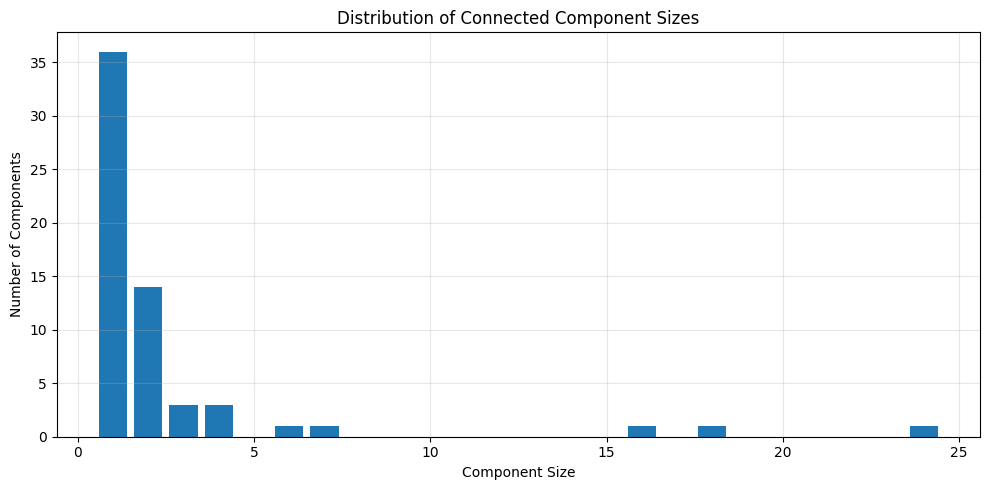

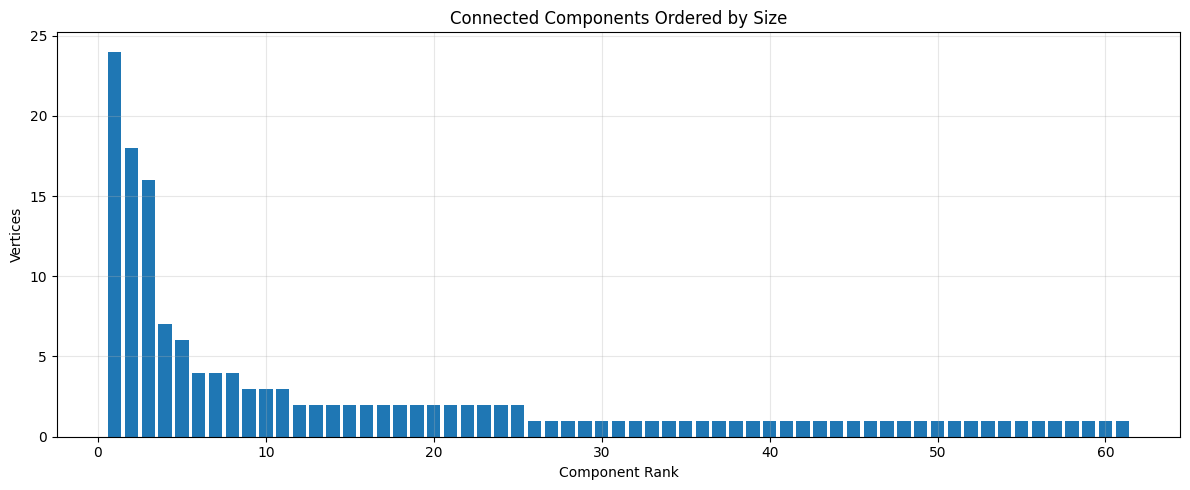

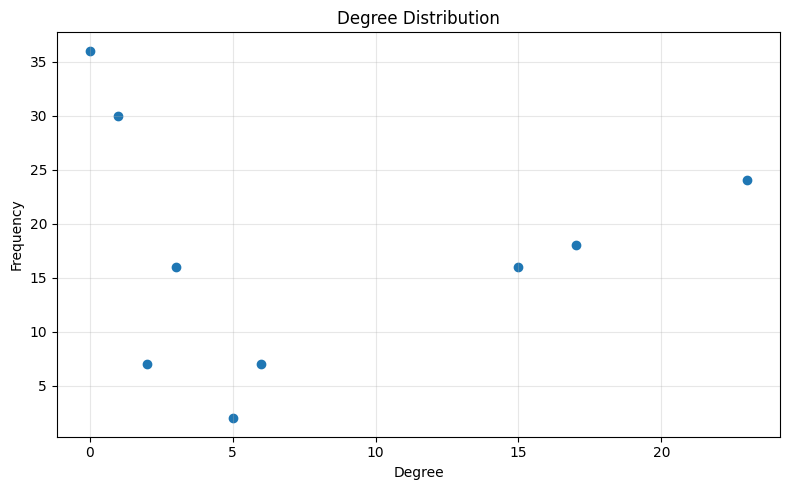

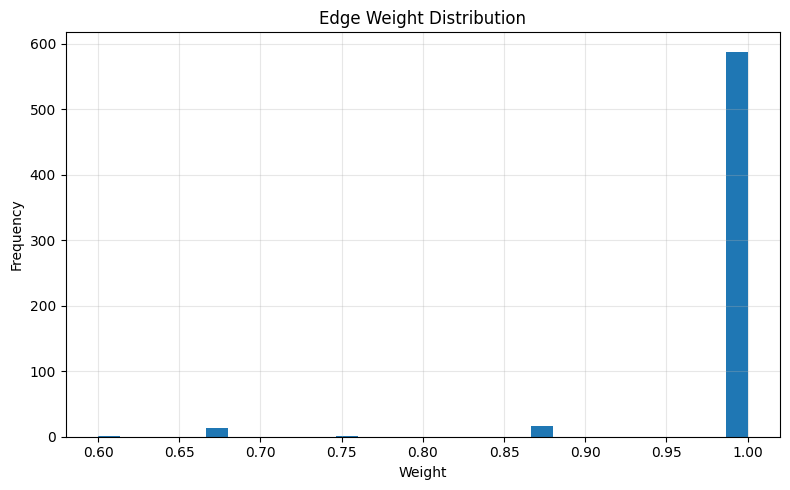

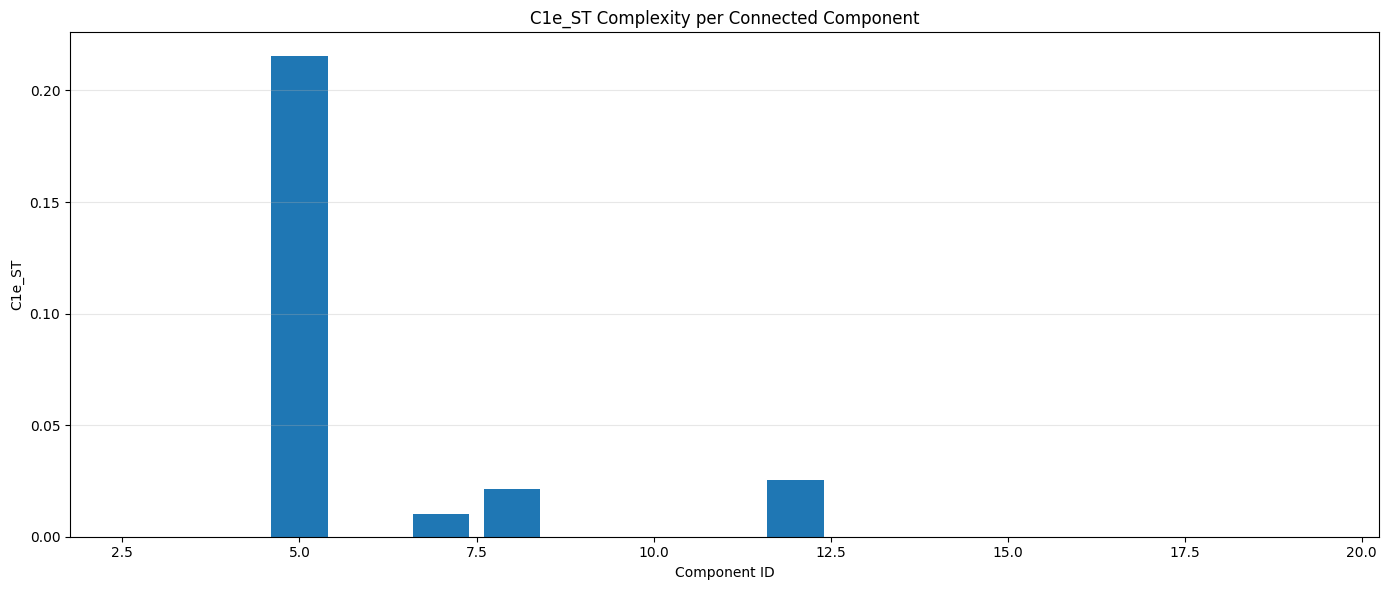

In [4]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter

# ==========================================================
# COMPLEXITY FUNCTIONS
# ==========================================================

def get_m_cu(n):

    return (n ** 1.68) - 10


# ==========================================================
# C1e_ST
# ==========================================================

def calculate_C1e_ST(graph):

    n = graph.vcount()

    if n < 4:
        return 0.0

    m_cu = get_m_cu(n)

    unique_spanning_trees = set()

    for edge in graph.es:

        g_prime = graph.copy()

        g_prime.delete_edges(edge.index)

        L = np.array(g_prime.laplacian())

        L_reduced = L[1:, 1:]

        num_trees = round(abs(np.linalg.det(L_reduced)))

        unique_spanning_trees.add(num_trees)

    N_1e_ST = len(unique_spanning_trees)

    return max(
        0.0,
        float((N_1e_ST - 1)/(m_cu - 1))
    )


# ==========================================================
# C1e_SPEC
# ==========================================================

def calculate_C1e_spec(graph):

    n = graph.vcount()

    if n < 4:
        return 0.0

    m_cu = get_m_cu(n)

    unique_spectra = set()

    for edge in graph.es:

        g_prime = graph.copy()

        g_prime.delete_edges(edge.index)

        L = np.array(g_prime.laplacian())

        A = np.array(
            g_prime.get_adjacency().data
        )

        D = np.diag(g_prime.degree())

        Q = D + A

        eigvals_L = tuple(
            np.round(
                np.sort(
                    np.linalg.eigvalsh(L)
                ),
                5
            )
        )

        eigvals_Q = tuple(
            np.round(
                np.sort(
                    np.linalg.eigvalsh(Q)
                ),
                5
            )
        )

        unique_spectra.add(
            (eigvals_L, eigvals_Q)
        )

    N_1e_spec = len(unique_spectra)

    return max(
        0.0,
        float((N_1e_spec - 1)/(m_cu - 1))
    )


# ==========================================================
# HISTOGRAM 1
# DISTRIBUTION OF COMPONENT SIZES
# ==========================================================

def plot_component_size_distribution(graph):

    sizes = graph.connected_components().sizes()

    freq = Counter(sizes)

    x = sorted(freq.keys())

    y = [freq[k] for k in x]

    plt.figure(figsize=(10,5))

    plt.bar(x, y)

    plt.xlabel("Component Size")

    plt.ylabel("Number of Components")

    plt.title(
        "Distribution of Connected Component Sizes"
    )

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.show()


# ==========================================================
# HISTOGRAM 2
# COMPONENTS SORTED BY SIZE
# ==========================================================

def plot_component_ranking(graph):

    sizes = sorted(
        graph.connected_components().sizes(),
        reverse=True
    )

    plt.figure(figsize=(12,5))

    plt.bar(
        range(1, len(sizes)+1),
        sizes
    )

    plt.xlabel("Component Rank")

    plt.ylabel("Vertices")

    plt.title(
        "Connected Components Ordered by Size"
    )

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.show()


# ==========================================================
# DEGREE DISTRIBUTION
# ==========================================================

def plot_degree_distribution(graph):

    degrees = graph.degree()

    freq = Counter(degrees)

    x = sorted(freq.keys())

    y = [freq[k] for k in x]

    plt.figure(figsize=(8,5))

    plt.scatter(x, y)

    plt.xlabel("Degree")

    plt.ylabel("Frequency")

    plt.title("Degree Distribution")

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.show()


# ==========================================================
# EDGE WEIGHT DISTRIBUTION
# ==========================================================

def plot_edge_weight_distribution(graph):

    if "weight" not in graph.es.attributes():
        return

    plt.figure(figsize=(8,5))

    plt.hist(
        graph.es["weight"],
        bins=30
    )

    plt.xlabel("Weight")

    plt.ylabel("Frequency")

    plt.title(
        "Edge Weight Distribution"
    )

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.show()


# ==========================================================
# COMPONENT ANALYSIS
# ==========================================================

def analyze_components(graph):

    components = graph.connected_components()

    subgraphs = components.subgraphs()

    sizes = components.sizes()

    print("\n")
    print("="*60)
    print("GLOBAL COMPONENT ANALYSIS")
    print("="*60)

    print(
        "Number of components:",
        len(sizes)
    )

    print(
        "Largest component:",
        max(sizes)
    )

    print(
        "Average component size:",
        np.mean(sizes)
    )

    print(
        "Median component size:",
        np.median(sizes)
    )

    print(
        "Singleton components:",
        sum(1 for s in sizes if s == 1)
    )

    print(
        "Components size 2:",
        sum(1 for s in sizes if s == 2)
    )

    print(
        "Components >=5:",
        sum(1 for s in sizes if s >= 5)
    )

    print(
        "Components >=10:",
        sum(1 for s in sizes if s >= 10)
    )

    giant_ratio = max(sizes) / graph.vcount()

    print(
        "Giant Component Ratio:",
        round(giant_ratio,4)
    )

    print("="*60)

    # ------------------------------------------------------

    giant = components.giant()

    print("\nGIANT COMPONENT")

    print(
        "Nodes:",
        giant.vcount()
    )

    print(
        "Edges:",
        giant.ecount()
    )

    print(
        "Density:",
        round(giant.density(),6)
    )

    try:

        print(
            "Average Path Length:",
            round(
                giant.average_path_length(),
                4
            )
        )

    except:

        pass

    try:

        print(
            "Diameter:",
            giant.diameter()
        )

    except:

        pass

    try:

        print(
            "Average Clustering:",
            round(
                giant.transitivity_avglocal_undirected(),
                4
            )
        )

    except:

        pass

    print("="*60)

    # ------------------------------------------------------
    # COMPLEXITY PER COMPONENT
    # ------------------------------------------------------

    valid_st = []

    valid_spec = []

    for idx, comp in enumerate(subgraphs):

        n = comp.vcount()

        if n < 4:
            continue

        c_st = calculate_C1e_ST(comp)

        c_spec = calculate_C1e_spec(comp)

        valid_st.append(c_st)

        valid_spec.append(c_spec)

        print(
            f"Component {idx+1}"
        )

        print(
            f"   Nodes={n}"
        )

        print(
            f"   Edges={comp.ecount()}"
        )

        print(
            f"   C1e_ST={c_st:.4f}"
        )

        print(
            f"   C1e_SPEC={c_spec:.4f}"
        )

    print("\n")

    if len(valid_st) > 0:

        print(
            "Average C1e_ST:",
            np.mean(valid_st)
        )

        print(
            "Average C1e_SPEC:",
            np.mean(valid_spec)
        )


# ==========================================================
# MAIN
# ==========================================================

if __name__ == "__main__":

    # Tu grafo
    graph = G

    # ----------------------------------
    # REPORT
    # ----------------------------------

    analyze_components(graph)

    # ----------------------------------
    # PLOTS
    # ----------------------------------

    plot_component_size_distribution(graph)

    plot_component_ranking(graph)

    plot_degree_distribution(graph)

    plot_edge_weight_distribution(graph)

    plot_C1e_ST_per_component(G)
    

In [1]:
import matplotlib.pyplot as plt

def plot_C1e_ST_per_component(graph):

    components = graph.connected_components().subgraphs()

    component_ids = []
    c1e_values = []

    for idx, comp in enumerate(components):

        if comp.vcount() < 4:
            continue

        c_st = calculate_C1e_ST(comp)

        component_ids.append(idx + 1)
        c1e_values.append(c_st)

    plt.figure(figsize=(14,6))

    plt.bar(
        component_ids,
        c1e_values
    )

    plt.xlabel("Component ID")

    plt.ylabel("C1e_ST")

    plt.title(
        "C1e_ST Complexity per Connected Component"
    )

    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()

    plt.show()